In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

## Roadmap

1. Load an edm4hep file
2. Load the particles and tracker hits
3. Inspect Higgs-portal truth particles (e.g. PDG 35/36 and the displaced b-jets from 36 → b b̄)


## Loading

In [22]:
# Load the edm4hep file with uproot
edm_input_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/higgs_portal/v1/runs/0/edm4hep.root"
event = EDM4hepEventBatch(edm_input_file, events=(0, 9), condense_calo=False, full_load=True)


In [23]:
tracker_hits = event.get_tracker_hits_df()
calo_hits = event.get_calo_hits_df()
particles = event.get_particles_df()
daughters = event.get_daughters_df()
parents = event.get_parents_df()

In [15]:
particles.PDG.unique()

array([      2212,         21,       2101,          2,        213,
             -211,        111,        211,       2114,      -2112,
            -2212,        113,       2112,         -2,       -213,
              223,        221,         -1,          1,        311,
             -311,        323,       -321,       2214,      -2114,
               22,        130,         35,        331,      -2224,
              321,       -313,        310,         36,          5,
               -5,       -531,        523,        431,       -411,
              521,       -513,         11,        -12,       -423,
             2224,       -511,       -421,        -14,         13,
              413,        411,      20213,        -11, 1000140280,
              -13, 1000010020, 1000020030, 1000010030,         14,
             3322,       3122, 1000120250], dtype=int32)

In [16]:
particles.columns

Index(['event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time',
       'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin',
       'parents_end', 'generatorStatus', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'daughters_begin', 'daughters_end', 'vr', 'endpoint_r',
       'energy', 'kinetic_energy', 'particle_id', 'created_in_simulation',
       'num_tracker_hits', 'num_calo_hits'],
      dtype='object')

In [17]:
particles[particles.PDG == 36]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,daughters_begin,daughters_end,vr,endpoint_r,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
384,0,384,36,0,0.0,0.209118,55.0,-0.020831,-0.030924,-65.98809,...,1315,1317,0.037286,3.059550,84.504500,29.504500,384,False,0,0
385,0,385,36,0,0.0,0.209118,55.0,-0.020831,-0.030924,-65.98809,...,1317,1319,0.037286,103.875347,66.844952,11.844952,385,False,0,0


In [18]:
daughters.iloc[1315:1317]

,event_id,subentry,particle_id,collectionID
1315,0,1315,386,2714477136
1316,0,1316,387,2714477136


In [20]:
daughters.iloc[1317:1319]

,event_id,subentry,particle_id,collectionID
1317,0,1317,388,2714477136
1318,0,1318,389,2714477136


In [19]:
particles.iloc[386:388]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,daughters_begin,daughters_end,vr,endpoint_r,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
386,0,386,5,0,-0.333333,0.224956,4.8,-0.349017,-3.039578,-64.029819,...,1319,1320,3.05955,3.05955,51.694807,46.894807,386,False,0,0
387,0,387,-5,0,0.333333,0.224956,4.8,-0.349017,-3.039578,-64.029819,...,1320,1322,3.05955,3.05955,32.809693,28.009693,387,False,0,0


In [21]:
particles.iloc[388:390]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,daughters_begin,daughters_end,vr,endpoint_r,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
388,0,388,5,0,-0.333333,0.850758,4.8,97.865932,-34.818774,-31.934521,...,1322,1324,103.875347,103.875347,46.379736,41.579736,388,False,0,0
389,0,389,-5,0,0.333333,0.850758,4.8,97.865932,-34.818774,-31.934521,...,1324,1325,103.875347,103.875347,20.465216,15.665216,389,False,0,0


In [24]:
daughters

,event_id,subentry,particle_id,collectionID
0,0,0,1,2714477136
1,0,1,2,2714477136
2,0,2,3,2714477136
3,0,3,8,2714477136
4,0,4,9,2714477136
...,...,...,...,...
70048,7,13449,8447,2714477136
70049,7,13450,8454,2714477136
70050,7,13451,8458,2714477136
70051,7,13452,8459,2714477136


In [26]:
event_particles = particles[particles.event_id == 2]

In [27]:
event_daughters = daughters[daughters.event_id == 2]

In [28]:
event_particles[event_particles.PDG == 36]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,daughters_begin,daughters_end,vr,endpoint_r,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
8000,2,1549,36,0,0.0,-0.248119,55.0,0.002833,-0.009228,59.477153,...,6508,6510,0.009653,50.244889,62.581592,7.581592,1549,False,0,0
8001,2,1550,36,0,0.0,-0.248119,55.0,0.002833,-0.009228,59.477153,...,6510,6512,0.009653,77.393477,66.979673,11.979673,1550,False,0,0


In [30]:
event_daughters.iloc[6508:6510]

,event_id,subentry,particle_id,collectionID
15751,2,6508,1551,2714477136
15752,2,6509,1552,2714477136


In [31]:
event_particles.iloc[1551:1553]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,daughters_begin,daughters_end,vr,endpoint_r,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
8002,2,1551,5,0,-0.333333,0.137928,4.8,49.497642,-8.633212,36.571257,...,6512,6513,50.244889,50.244889,23.856018,19.056018,1551,False,0,0
8003,2,1552,-5,0,0.333333,0.137928,4.8,49.497642,-8.633212,36.571257,...,6513,6515,50.244889,50.244889,38.725574,33.925574,1552,False,0,0


In [32]:
a_particles = particles[particles.PDG == 36].copy()

# IMPORTANT: daughters_begin/end are per-event offsets, so slice daughters within each event
rows = []
for a in a_particles.itertuples(index=False):
    dau_event = daughters[daughters.event_id == a.event_id].reset_index(drop=True)
    dau_slice = dau_event.iloc[int(a.daughters_begin):int(a.daughters_end)]
    dau_ids = dau_slice["particle_id"].to_list()

    particles_event = particles[particles.event_id == a.event_id]
    dau_particles = particles_event[particles_event.particle_id.isin(dau_ids)].copy()

    for d in dau_particles.itertuples(index=False):
        rows.append({
            "event_id": a.event_id,
            "a_particle_id": a.particle_id,
            "a_vx": a.vx,
            "a_vy": a.vy,
            "a_vz": a.vz,
            "a_endpoint_x": a.endpoint_x,
            "a_endpoint_y": a.endpoint_y,
            "a_endpoint_z": a.endpoint_z,
            "a_vr": a.vr,
            "a_endpoint_r": a.endpoint_r,
            "daughter_particle_id": d.particle_id,
            "daughter_PDG": d.PDG,
            "daughter_vx": d.vx,
            "daughter_vy": d.vy,
            "daughter_vz": d.vz,
        })

children_vtx = pd.DataFrame(rows)
children_vtx.sort_values(["event_id", "a_particle_id", "daughter_particle_id"], inplace=True)
children_vtx

,event_id,a_particle_id,a_vx,a_vy,a_vz,a_endpoint_x,a_endpoint_y,a_endpoint_z,a_vr,a_endpoint_r,daughter_particle_id,daughter_PDG,daughter_vx,daughter_vy,daughter_vz
0,0,384,-0.020831,-0.030924,-65.988090,-0.349017,-3.039578,-64.029819,0.037286,3.059550,386,5,-0.349017,-3.039578,-64.029819
1,0,384,-0.020831,-0.030924,-65.988090,-0.349017,-3.039578,-64.029819,0.037286,3.059550,387,-5,-0.349017,-3.039578,-64.029819
2,0,385,-0.020831,-0.030924,-65.988090,97.865932,-34.818774,-31.934521,0.037286,103.875347,388,5,97.865932,-34.818774,-31.934521
3,0,385,-0.020831,-0.030924,-65.988090,97.865932,-34.818774,-31.934521,0.037286,103.875347,389,-5,97.865932,-34.818774,-31.934521
4,1,1057,-0.000727,-0.023050,-112.986232,-1.363289,1.020622,-120.831292,0.023061,1.703005,1059,5,-1.363289,1.020622,-120.831292
5,1,1057,-0.000727,-0.023050,-112.986232,-1.363289,1.020622,-120.831292,0.023061,1.703005,1060,-5,-1.363289,1.020622,-120.831292
6,1,1058,-0.000727,-0.023050,-112.986232,-0.000518,-0.048904,-113.012336,0.023061,0.048907,1061,5,-0.000518,-0.048904,-113.012336
7,1,1058,-0.000727,-0.023050,-112.986232,-0.000518,-0.048904,-113.012336,0.023061,0.048907,1062,-5,-0.000518,-0.048904,-113.012336
8,2,1549,0.002833,-0.009228,59.477153,49.497642,-8.633212,36.571257,0.009653,50.244889,1551,5,49.497642,-8.633212,36.571257
9,2,1549,0.002833,-0.009228,59.477153,49.497642,-8.633212,36.571257,0.009653,50.244889,1552,-5,49.497642,-8.633212,36.571257


<Axes: ylabel='Count'>

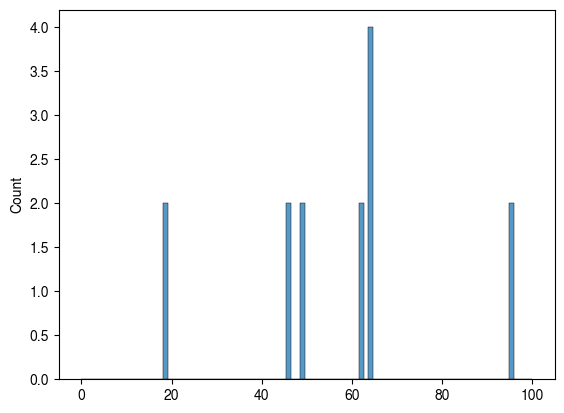

In [34]:
children_radius = np.sqrt(children_vtx.daughter_vx**2 + children_vtx.daughter_vy**2 + children_vtx.daughter_vz**2)

sns.histplot(children_radius, bins=np.linspace(0, 100, 100))

In [ ]:
tracker_hits

,event_id,subentry,cellID,time,x,y,z,detector,particle_id,r,R,phi,theta,eta
0,0,0,60077547270377222,0.144050,30.402032,-9.939022,2.208908,PixelBarrelReadout,335,31.985429,32.061612,-0.315967,1.501846,0.069005
1,0,1,6649970879241750,0.292478,63.335321,-24.882639,-17.336838,PixelBarrelReadout,335,68.047840,70.221610,-0.374346,1.820263,-0.252096
2,0,2,70070007727796262,0.481834,102.399987,-49.665924,-41.886809,PixelBarrelReadout,335,113.808881,121.272281,-0.451591,1.923456,-0.360205
3,0,3,59497099620140854,0.716374,145.373103,-87.735785,-71.972332,PixelBarrelReadout,335,169.796664,184.420507,-0.543005,1.971713,-0.412109
4,0,4,6122261132484118,0.302634,63.569908,-24.275881,-18.914919,PixelBarrelReadout,1783,68.047422,70.627373,-0.364786,1.841919,-0.274506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6375,0,654,15663745823054,9.288465,-1020.603412,66.962789,2604.500000,LongStripEndcapReadout,1759,1022.797800,2798.130731,3.076076,0.374201,1.664344
6376,0,655,15685221708110,9.306403,-1022.580861,66.846928,2609.500000,LongStripEndcapReadout,1759,1024.763450,2803.503233,3.076315,0.374202,1.664342
6377,0,656,15706696548686,9.345511,-1026.930085,66.588938,2620.500000,LongStripEndcapReadout,1759,1029.086724,2815.322315,3.076841,0.374203,1.664339
6378,0,657,15668040794446,9.363808,-1028.907160,66.468849,2625.500000,LongStripEndcapReadout,1759,1031.051915,2820.694649,3.077081,0.374203,1.664338
